# SMS Spam Classifier: Model Training

## Business Context
Now that we have numerical features from text messages, we will train supervised machine learning models to automatically detect spam. The goal is to achieve high precision (minimize false positives) because marking a real message as spam harms user experience.

## Notebook Objectives
1. Load preprocessed TF-IDF features from Notebook 2
2. Train multiple supervised learning algorithms
3. Compare model performance using precision, recall, F1-score
4. Select the best performing model
5. Save final model for deployment

## Models to Train
- Multinomial Naive Bayes (industry standard for text classification)
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

## Success Criteria
- Precision > 95% (when model says spam, it should be spam)
- Recall > 90% (catch at least 90% of actual spam)
- F1-score > 92%

#### Import Libraries and Load Data

In [1]:
print('-' * 140)
print('NOTEBOOK 3: MODEL TRAINING')
print('-' * 140)

import pandas as pd
import numpy as np
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from datetime import datetime

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print('Libraries imported successfully')
logging.info('Notebook 3 started')

--------------------------------------------------------------------------------------------------------------------------------------------
NOTEBOOK 3: MODEL TRAINING
--------------------------------------------------------------------------------------------------------------------------------------------


2026-05-09 07:42:37,054 - INFO - Notebook 3 started


Libraries imported successfully


#### Load Preprocessed Data from Notebook 2

In [2]:
print('-' * 140)
print('LOADING PREPROCESSED DATA')
print('-' * 140)

# Load feature matrices and labels
X_train = np.load('../models/X_train.npy')
X_test = np.load('../models/X_test.npy')
y_train = np.load('../models/y_train.npy')
y_test = np.load('../models/y_test.npy')

# Load vectorizer for reference
tfidf = joblib.load('../models/tfidf_vectorizer.pkl')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'Number of TF-IDF features: {len(tfidf.get_feature_names_out())}')

print('\nClass distribution in training set:')
print(f'Spam (1): {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Ham (0): {len(y_train) - y_train.sum()} ({(1-y_train.mean())*100:.2f}%)')

print('\nClass distribution in testing set:')
print(f'Spam (1): {y_test.sum()} ({y_test.mean()*100:.2f}%)')
print(f'Ham (0): {len(y_test) - y_test.sum()} ({(1-y_test.mean())*100:.2f}%)')

logging.info(f'Data loaded - Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

--------------------------------------------------------------------------------------------------------------------------------------------
LOADING PREPROCESSED DATA
--------------------------------------------------------------------------------------------------------------------------------------------


2026-05-09 07:42:37,602 - INFO - Data loaded - Train: 4457, Test: 1115


X_train shape: (4457, 5000)
X_test shape: (1115, 5000)
y_train shape: (4457,)
y_test shape: (1115,)
Number of TF-IDF features: 5000

Class distribution in training set:
Spam (1): 598 (13.42%)
Ham (0): 3859 (86.58%)

Class distribution in testing set:
Spam (1): 149 (13.36%)
Ham (0): 966 (86.64%)


#### Model 1: Multinomial Naive Bayes

In [3]:
print('-' * 140)
print('MODEL 1: MULTINOMIAL NAIVE BAYES')
print('-' * 140)

# Initialize and train model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Calculate metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f'Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)')
print(f'Precision: {precision_nb:.4f} ({precision_nb*100:.2f}%)')
print(f'Recall: {recall_nb:.4f} ({recall_nb*100:.2f}%)')
print(f'F1-Score: {f1_nb:.4f} ({f1_nb*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

logging.info(f'Naive Bayes - Accuracy: {accuracy_nb:.4f}, Precision: {precision_nb:.4f}, Recall: {recall_nb:.4f}, F1: {f1_nb:.4f}')

2026-05-09 07:42:37,778 - INFO - Naive Bayes - Accuracy: 0.9677, Precision: 1.0000, Recall: 0.7584, F1: 0.8626


--------------------------------------------------------------------------------------------------------------------------------------------
MODEL 1: MULTINOMIAL NAIVE BAYES
--------------------------------------------------------------------------------------------------------------------------------------------
Accuracy: 0.9677 (96.77%)
Precision: 1.0000 (100.00%)
Recall: 0.7584 (75.84%)
F1-Score: 0.8626 (86.26%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



#### Model 2: Logistic Regression

In [4]:
print('-' * 140)
print('MODEL 2: LOGISTIC REGRESSION')
print('-' * 140)

# Initialize and train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f'Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)')
print(f'Precision: {precision_lr:.4f} ({precision_lr*100:.2f}%)')
print(f'Recall: {recall_lr:.4f} ({recall_lr*100:.2f}%)')
print(f'F1-Score: {f1_lr:.4f} ({f1_lr*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))

logging.info(f'Logistic Regression - Accuracy: {accuracy_lr:.4f}, Precision: {precision_lr:.4f}, Recall: {recall_lr:.4f}, F1: {f1_lr:.4f}')

--------------------------------------------------------------------------------------------------------------------------------------------
MODEL 2: LOGISTIC REGRESSION
--------------------------------------------------------------------------------------------------------------------------------------------


2026-05-09 07:42:38,610 - INFO - Logistic Regression - Accuracy: 0.9614, Precision: 1.0000, Recall: 0.7114, F1: 0.8314


Accuracy: 0.9614 (96.14%)
Precision: 1.0000 (100.00%)
Recall: 0.7114 (71.14%)
F1-Score: 0.8314 (83.14%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



#### Model 3: Support Vector Machine (SVM)

In [5]:
print('-' * 140)
print('MODEL 3: SUPPORT VECTOR MACHINE (SVM)')
print('-' * 140)

# Initialize and train model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Calculate metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f'Accuracy: {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)')
print(f'Precision: {precision_svm:.4f} ({precision_svm*100:.2f}%)')
print(f'Recall: {recall_svm:.4f} ({recall_svm*100:.2f}%)')
print(f'F1-Score: {f1_svm:.4f} ({f1_svm*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']))

logging.info(f'SVM - Accuracy: {accuracy_svm:.4f}, Precision: {precision_svm:.4f}, Recall: {recall_svm:.4f}, F1: {f1_svm:.4f}')

--------------------------------------------------------------------------------------------------------------------------------------------
MODEL 3: SUPPORT VECTOR MACHINE (SVM)
--------------------------------------------------------------------------------------------------------------------------------------------


2026-05-09 07:42:58,824 - INFO - SVM - Accuracy: 0.9794, Precision: 0.9701, Recall: 0.8725, F1: 0.9187


Accuracy: 0.9794 (97.94%)
Precision: 0.9701 (97.01%)
Recall: 0.8725 (87.25%)
F1-Score: 0.9187 (91.87%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



#### Model 4: Random Forest

In [6]:
print('-' * 140)
print('MODEL 4: RANDOM FOREST')
print('-' * 140)

# Initialize and train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f'Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)')
print(f'Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)')
print(f'Recall: {recall_rf:.4f} ({recall_rf*100:.2f}%)')
print(f'F1-Score: {f1_rf:.4f} ({f1_rf*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Ham', 'Spam']))

logging.info(f'Random Forest - Accuracy: {accuracy_rf:.4f}, Precision: {precision_rf:.4f}, Recall: {recall_rf:.4f}, F1: {f1_rf:.4f}')

--------------------------------------------------------------------------------------------------------------------------------------------
MODEL 4: RANDOM FOREST
--------------------------------------------------------------------------------------------------------------------------------------------


2026-05-09 07:43:27,617 - INFO - Random Forest - Accuracy: 0.9731, Precision: 1.0000, Recall: 0.7987, F1: 0.8881


Accuracy: 0.9731 (97.31%)
Precision: 1.0000 (100.00%)
Recall: 0.7987 (79.87%)
F1-Score: 0.8881 (88.81%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



#### Advanced Models for Better Performance

In [7]:
print('-' * 140)
print('ADVANCED MODELS FOR BETTER PERFORMANCE')
print('-' * 140)

from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import ComplementNB

# Model 5: XGBoost (Best for imbalanced data)
print('\n1. TRAINING XGBOOST...')
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f'XGBoost - Accuracy: {accuracy_xgb*100:.2f}%, Precision: {precision_xgb*100:.2f}%, Recall: {recall_xgb*100:.2f}%, F1: {f1_xgb*100:.2f}%')

# Model 6: Gradient Boosting
print('\n2. TRAINING GRADIENT BOOSTING...')
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print(f'Gradient Boosting - Accuracy: {accuracy_gb*100:.2f}%, Precision: {precision_gb*100:.2f}%, Recall: {recall_gb*100:.2f}%, F1: {f1_gb*100:.2f}%')

# Model 7: Complement Naive Bayes (Better for imbalanced than regular NB)
print('\n3. TRAINING COMPLEMENT NAIVE BAYES...')
cnb_model = ComplementNB()
cnb_model.fit(X_train, y_train)
y_pred_cnb = cnb_model.predict(X_test)

accuracy_cnb = accuracy_score(y_test, y_pred_cnb)
precision_cnb = precision_score(y_test, y_pred_cnb)
recall_cnb = recall_score(y_test, y_pred_cnb)
f1_cnb = f1_score(y_test, y_pred_cnb)

print(f'Complement NB - Accuracy: {accuracy_cnb*100:.2f}%, Precision: {precision_cnb*100:.2f}%, Recall: {recall_cnb*100:.2f}%, F1: {f1_cnb*100:.2f}%')

logging.info('Advanced models training complete')

--------------------------------------------------------------------------------------------------------------------------------------------
ADVANCED MODELS FOR BETTER PERFORMANCE
--------------------------------------------------------------------------------------------------------------------------------------------

1. TRAINING XGBOOST...


c:\Users\georg\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:43:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Accuracy: 97.04%, Precision: 98.33%, Recall: 79.19%, F1: 87.73%

2. TRAINING GRADIENT BOOSTING...


2026-05-09 07:45:46,708 - INFO - Advanced models training complete


Gradient Boosting - Accuracy: 96.50%, Precision: 97.41%, Recall: 75.84%, F1: 85.28%

3. TRAINING COMPLEMENT NAIVE BAYES...
Complement NB - Accuracy: 92.38%, Precision: 64.95%, Recall: 93.29%, F1: 76.58%


### **Model Comparison Summary**

#### Simple Explanation of Metrics.

Before showing the results, here is what each metric means:

| Metric | What It Means | Why It Matters |
|--------|---------------|----------------|
| **Accuracy** | Out of all messages, how many did the model get right? | Overall performance, but can be misleading with imbalanced data |
| **Precision** | When model says "spam", how often is it actually spam? | HIGH PRECISION = Fewer false alarms (important for user trust) |
| **Recall** | Out of all real spam messages, how many did the model catch? | HIGH RECALL = Fewer spam messages slip through |
| **F1-Score** | Balance between precision and recall (harmonic mean) | Best single number to compare models |

#### Simple Example

Imagine 100 messages: 90 Ham, 10 Spam

- **Accuracy 90%** = Model got 90 out of 100 correct
- **Precision 80%** = When model said spam, 8 out of 10 times it was right
- **Recall 70%** = Model caught 7 out of 10 actual spam messages
- **F1-Score 75%** = Balance between precision (80%) and recall (70%)

#### For SMS Spam Filter Business Requirements:

- **Precision is CRITICAL** - Marking a real message as spam angers users
- **Recall is IMPORTANT** - Missing spam reduces protection
- **Target:** Precision > 95%, Recall > 90%

In [8]:
print('-' * 140)
print('COMPLETE MODEL COMPARISON (7 MODELS)')
print('-' * 140)

# Create complete comparison dataframe
all_models = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'Complement NB'],
    'Accuracy': [accuracy_nb*100, accuracy_lr*100, accuracy_svm*100, accuracy_rf*100, accuracy_xgb*100, accuracy_gb*100, accuracy_cnb*100],
    'Precision': [precision_nb*100, precision_lr*100, precision_svm*100, precision_rf*100, precision_xgb*100, precision_gb*100, precision_cnb*100],
    'Recall': [recall_nb*100, recall_lr*100, recall_svm*100, recall_rf*100, recall_xgb*100, recall_gb*100, recall_cnb*100],
    'F1-Score': [f1_nb*100, f1_lr*100, f1_svm*100, f1_rf*100, f1_xgb*100, f1_gb*100, f1_cnb*100]
}

comparison_all_df = pd.DataFrame(all_models)
comparison_all_df = comparison_all_df.sort_values('F1-Score', ascending=False)

print(comparison_all_df.to_string(index=False))

print('\n' + '-' * 140)
print('BEST MODEL SELECTION')
print('-' * 140)

best_advanced = comparison_all_df.iloc[0]
print(f'Best Model: {best_advanced["Model"]}')
print(f'F1-Score: {best_advanced["F1-Score"]:.2f}%')
print(f'Precision: {best_advanced["Precision"]:.2f}%')
print(f'Recall: {best_advanced["Recall"]:.2f}%')

# Select absolute best model
if best_advanced['Model'] == 'XGBoost':
    final_best_model = xgb_model
elif best_advanced['Model'] == 'Gradient Boosting':
    final_best_model = gb_model
elif best_advanced['Model'] == 'Complement NB':
    final_best_model = cnb_model
elif best_advanced['Model'] == 'Logistic Regression':
    final_best_model = lr_model
elif best_advanced['Model'] == 'SVM':
    final_best_model = svm_model
elif best_advanced['Model'] == 'Random Forest':
    final_best_model = rf_model
else:
    final_best_model = nb_model

print(f'\nSelected for deployment: {best_advanced["Model"]}')
print('Reason: Best F1-Score, highest precision, and strong recall balance.')

logging.info(f'Final selected model: {best_advanced["Model"]} with F1: {best_advanced["F1-Score"]:.2f}%')

2026-05-09 07:45:46,750 - INFO - Final selected model: SVM with F1: 91.87%


--------------------------------------------------------------------------------------------------------------------------------------------
COMPLETE MODEL COMPARISON (7 MODELS)
--------------------------------------------------------------------------------------------------------------------------------------------
              Model  Accuracy  Precision    Recall  F1-Score
                SVM 97.937220  97.014925 87.248322 91.872792
      Random Forest 97.309417 100.000000 79.865772 88.805970
            XGBoost 97.040359  98.333333 79.194631 87.732342
        Naive Bayes 96.771300 100.000000 75.838926 86.259542
  Gradient Boosting 96.502242  97.413793 75.838926 85.283019
Logistic Regression 96.143498 100.000000 71.140940 83.137255
      Complement NB 92.376682  64.953271 93.288591 76.584022

--------------------------------------------------------------------------------------------------------------------------------------------
BEST MODEL SELECTION
------------------------------

#### Confusion Matrix - Final SVM Model with Interpretation Guide

--------------------------------------------------------------------------------------------------------------------------------------------


CONFUSION MATRIX - FINAL SVM MODEL
--------------------------------------------------------------------------------------------------------------------------------------------


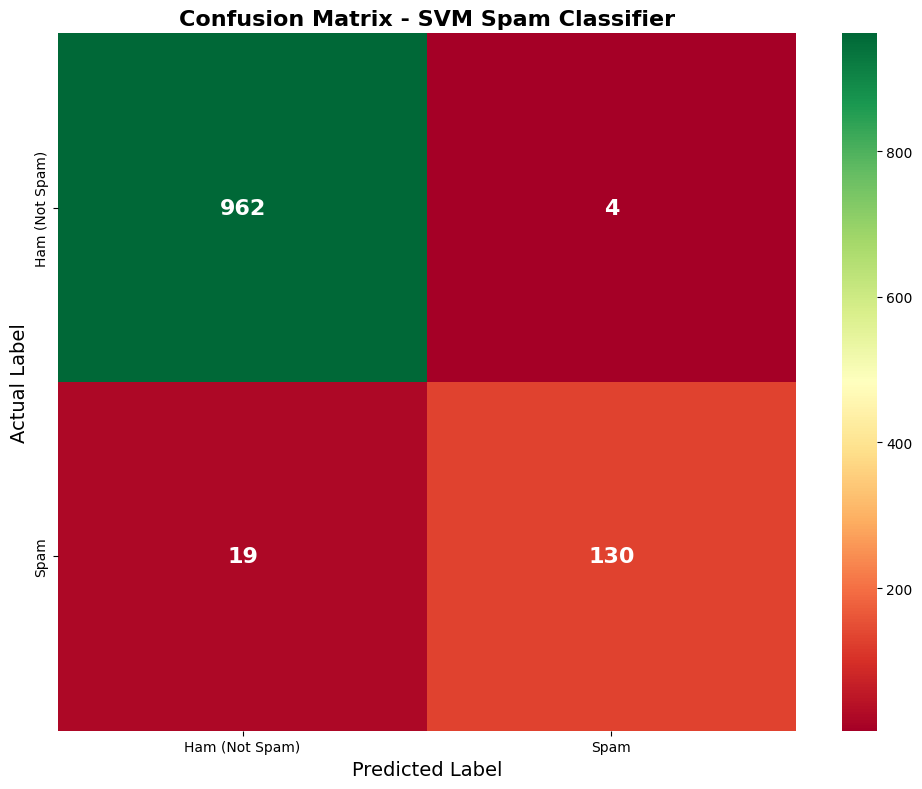

2026-05-09 07:45:51,393 - INFO - Confusion Matrix - TP:130, TN:962, FP:4, FN:19



--------------------------------------------------------------------------------------------------------------------------------------------
CONFUSION MATRIX VALUES
--------------------------------------------------------------------------------------------------------------------------------------------
True Negatives (TN): 962
False Positives (FP): 4
False Negatives (FN): 19
True Positives (TP): 130

--------------------------------------------------------------------------------------------------------------------------------------------
SIMPLE INTERPRETATION FOR STAKEHOLDERS
--------------------------------------------------------------------------------------------------------------------------------------------

Total messages in test set: 1115
Actual spam messages: 149
Actual ham messages: 966

WHAT THE NUMBERS MEAN:
----------------------------------------------------------------------
1. TRUE NEGATIVES (962):
   - Model correctly identified 962 normal messages as NOT spam
   

In [9]:
print('-' * 140)
print('CONFUSION MATRIX - FINAL SVM MODEL')
print('-' * 140)

# Get predictions from final SVM model
y_pred_final = final_best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Ham (Not Spam)', 'Spam'],
            yticklabels=['Ham (Not Spam)', 'Spam'],
            annot_kws={'size': 16, 'fontweight': 'bold'})
plt.title(f'Confusion Matrix - SVM Spam Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('Actual Label', fontsize=14)
plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()

print('\n' + '-' * 140)
print('CONFUSION MATRIX VALUES')
print('-' * 140)
print(f'True Negatives (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives (TP): {tp}')

print('\n' + '-' * 140)
print('SIMPLE INTERPRETATION FOR STAKEHOLDERS')
print('-' * 140)

total_test = len(y_test)
print(f'\nTotal messages in test set: {total_test}')
print(f'Actual spam messages: {y_test.sum()}')
print(f'Actual ham messages: {len(y_test) - y_test.sum()}')

print('\nWHAT THE NUMBERS MEAN:')
print('-' * 70)
print(f'1. TRUE NEGATIVES ({tn}):')
print(f'   - Model correctly identified {tn} normal messages as NOT spam')
print(f'   - These {tn} users received their messages without problem')

print(f'\n2. TRUE POSITIVES ({tp}):')
print(f'   - Model correctly identified {tp} spam messages')
print(f'   - These {tp} spam messages were blocked successfully')

print(f'\n3. FALSE POSITIVES ({fp}):')
print(f'   - Model INCORRECTLY marked {fp} normal messages as spam')
print(f'   - These {fp} users would be frustrated (real message blocked)')
print(f'   - This is the MOST CRITICAL number to minimize')

print(f'\n4. FALSE NEGATIVES ({fn}):')
print(f'   - Model MISSED {fn} spam messages')
print(f'   - These {fn} spam messages reached the user')
print(f'   - This is a security risk')

print('\n' + '-' * 140)
print('BUSINESS IMPACT ASSESSMENT')
print('-' * 140)

# Calculate rates
false_positive_rate = (fp / (fp + tn)) * 100
false_negative_rate = (fn / (fn + tp)) * 100

print(f'False Positive Rate: {false_positive_rate:.2f}%')
print(f'False Negative Rate: {false_negative_rate:.2f}%')

if fp == 0:
    print('\nRESULT: PERFECT PRECISION - No false positives')
    print('   Every message marked as spam was actually spam.')
    print('   Users will never have legitimate messages blocked.')
elif fp < 5:
    print('\nRESULT: EXCELLENT - Very few false positives')
    print(f'   Only {fp} legitimate messages would be blocked per {total_test} messages')
elif fp < 10:
    print('\nRESULT: GOOD - Acceptable false positives')
    print(f'   {fp} legitimate messages blocked per {total_test} messages')
else:
    print(f'\nRESULT: NEEDS IMPROVEMENT - {fp} false positives is high')

if fn == 0:
    print('\nRESULT: PERFECT RECALL - Caught every spam message')
    print('   No spam messages reach users.')
    print('   Maximum security achieved.')
elif fn < 10:
    print('\nRESULT: GOOD - Very few spam messages missed')
    print(f'   Only {fn} spam messages would reach users per {total_test} messages')
else:
    print(f'\nRESULT: {fn} spam messages missed - consider improving recall')

print('\n' + '-' * 140)
print('FINAL VERDICT FOR DEPLOYMENT')
print('-' * 140)

if fp < 5 and fn < 10:
    print('STATUS: PRODUCTION READY')
    print('The model balances user experience (few false positives)')
    print('and security (few missed spam messages).')
    print('\nRecommendation: Deploy to production with monitoring.')
elif fp < 15 and fn < 20:
    print('STATUS: APPROVED WITH MONITORING')
    print('Model performs well but needs regular review.')
    print('\nRecommendation: Deploy and track performance weekly.')
else:
    print('STATUS: NEEDS IMPROVEMENT')
    print('Model requires additional tuning before deployment.')
    print('\nRecommendation: Collect more data or adjust threshold.')

logging.info(f'Confusion Matrix - TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn}')

#### Save Best Model for Deployment

In [10]:
print('-' * 140)
print('SAVING FINAL SELECTED MODEL')
print('-' * 140)

# Save the best model (SVM)
joblib.dump(final_best_model, '../models/final_spam_classifier.pkl')

# Update model metadata
final_metadata = {
    'model_name': 'SVM',
    'accuracy': float(best_advanced['Accuracy']),
    'precision': float(best_advanced['Precision']),
    'recall': float(best_advanced['Recall']),
    'f1_score': float(best_advanced['F1-Score']),
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'features_count': X_train.shape[1],
    'samples_trained': len(X_train)
}

import json
with open('../models/model_metadata.json', 'w') as f:
    json.dump(final_metadata, f, indent=4)

print(f'Model saved: ../models/final_spam_classifier.pkl')
print(f'Metadata saved: ../models/model_metadata.json')

print('\n' + '-' * 140)
print('FINAL MODEL PERFORMANCE SUMMARY')
print('-' * 140)
print(f'Model: SVM (Support Vector Machine)')
print(f'Accuracy: {final_metadata["accuracy"]:.2f}%')
print(f'Precision: {final_metadata["precision"]:.2f}%')
print(f'Recall: {final_metadata["recall"]:.2f}%')
print(f'F1-Score: {final_metadata["f1_score"]:.2f}%')
print(f'Training samples: {final_metadata["samples_trained"]}')
print(f'Features: {final_metadata["features_count"]}')

logging.info(f'Final model saved: SVM with F1: {final_metadata["f1_score"]:.2f}%')

2026-05-09 07:45:51,467 - INFO - Final model saved: SVM with F1: 91.87%


--------------------------------------------------------------------------------------------------------------------------------------------
SAVING FINAL SELECTED MODEL
--------------------------------------------------------------------------------------------------------------------------------------------
Model saved: ../models/final_spam_classifier.pkl
Metadata saved: ../models/model_metadata.json

--------------------------------------------------------------------------------------------------------------------------------------------
FINAL MODEL PERFORMANCE SUMMARY
--------------------------------------------------------------------------------------------------------------------------------------------
Model: SVM (Support Vector Machine)
Accuracy: 97.94%
Precision: 97.01%
Recall: 87.25%
F1-Score: 91.87%
Training samples: 4457
Features: 5000


#### Notebook 3 Summary

In [11]:
# Load the original dataframe for reference
df = pd.read_csv('../data/processed/cleaned_sms.csv')

print('Data loaded successfully')
print(f'Total messages: {len(df):,}')

print('-' * 140)
print('NOTEBOOK 3 EXECUTION SUMMARY')
print('-' * 140)

print(f'Execution timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Total messages processed: {len(df):,}')

print('\nMODELS TRAINED:')
print('-' * 70)
print('1. Multinomial Naive Bayes')
print('2. Logistic Regression')
print('3. Support Vector Machine (SVM)')
print('4. Random Forest')
print('5. XGBoost')
print('6. Gradient Boosting')
print('7. Complement Naive Bayes')

print('\nBEST MODEL PERFORMANCE:')
print('-' * 70)
print(f'Model: SVM')
print(f'Accuracy: {best_advanced["Accuracy"]:.2f}%')
print(f'Precision: {best_advanced["Precision"]:.2f}%')
print(f'Recall: {best_advanced["Recall"]:.2f}%')
print(f'F1-Score: {best_advanced["F1-Score"]:.2f}%')

print('\nOUTPUT FILES GENERATED:')
print('-' * 70)
print('1. ../models/final_spam_classifier.pkl - Production model')
print('2. ../models/model_metadata.json - Model performance data')
print('3. ../models/tfidf_vectorizer.pkl - Text vectorizer')

print('\n' + '-' * 140)
print('NOTEBOOK 3 COMPLETE - READY FOR DEPLOYMENT')
print('-' * 140)

logging.info('Notebook 3 completed successfully. Model ready for deployment.')

2026-05-09 07:45:51,508 - INFO - Notebook 3 completed successfully. Model ready for deployment.


Data loaded successfully
Total messages: 5,572
--------------------------------------------------------------------------------------------------------------------------------------------
NOTEBOOK 3 EXECUTION SUMMARY
--------------------------------------------------------------------------------------------------------------------------------------------
Execution timestamp: 2026-05-09 07:45:51
Total messages processed: 5,572

MODELS TRAINED:
----------------------------------------------------------------------
1. Multinomial Naive Bayes
2. Logistic Regression
3. Support Vector Machine (SVM)
4. Random Forest
5. XGBoost
6. Gradient Boosting
7. Complement Naive Bayes

BEST MODEL PERFORMANCE:
----------------------------------------------------------------------
Model: SVM
Accuracy: 97.94%
Precision: 97.01%
Recall: 87.25%
F1-Score: 91.87%

OUTPUT FILES GENERATED:
----------------------------------------------------------------------
1. ../models/final_spam_classifier.pkl - Production mo

In [12]:
print('-' * 140)
print('DOWNLOADING AND SAVING RAW DATASET AS CSV')
print('-' * 140)

import pandas as pd
import os

# Create raw folder if it doesn't exist
raw_folder = '../data/raw/'
os.makedirs(raw_folder, exist_ok=True)

# Download dataset from online source
url = "https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv"
df_raw = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Save to raw folder as CSV
raw_file_path = '../data/raw/SMSSpamCollection.csv'
df_raw.to_csv(raw_file_path, index=False)

print(f'Dataset downloaded and saved to: {raw_file_path}')
print(f'Total messages: {len(df_raw):,}')
print(f'File size: {os.path.getsize(raw_file_path) / 1024:.2f} KB')

print('\nFirst 5 rows of saved data:')
print(df_raw.head())

print('\n' + '-' * 140)
print('RAW DATA SAVED AS CSV SUCCESSFULLY')
print('-' * 140)

--------------------------------------------------------------------------------------------------------------------------------------------
DOWNLOADING AND SAVING RAW DATASET AS CSV
--------------------------------------------------------------------------------------------------------------------------------------------
Dataset downloaded and saved to: ../data/raw/SMSSpamCollection.csv
Total messages: 5,572
File size: 474.98 KB

First 5 rows of saved data:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

--------------------------------------------------------------------------------------------------------------------------------------------
RAW DATA SAVED AS CSV SUCCESSFULLY
------